## 1. USO DE APRENDIZAJE NO SUPERVISADO ##

El aprendizaje no supervisado es una rama fundamental en el campo de la inteligencia artificial y el análisis de datos. Se enfoca en identificar patrones y estructuras ocultas en conjuntos de datos sin la necesidad de etiquetas o supervisión externa. Esto lo hace invaluable en problemas de identificación de patrones, donde se busca comprender la estructura subyacente de los datos y descubrir relaciones inherentes entre las variables.

### Dataset: Student Productivity & Behavior Dataset ###

In [75]:
# librerías para uso de aprendizaje no supervisado y PCA
import os
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
import seaborn as sns

# descargar dataset Student_productivity
def prepare_data():
    file_path = "data/student_productivity_distraction_dataset_20000.csv"
    _df = pd.read_csv(file_path)
    return _df
df = prepare_data()
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [76]:
# verificar estado de datos
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [77]:
#eliminar columna 'student_id' ya que no aporta información relevante para el análisis
df = df.drop(columns=['student_id'])
#eliminar columna "gender" para verificar el peso de las otras variables.
df = df.drop(columns=['gender'])

df.describe()

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


### PCA ###

In [78]:
# Escalado de características
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

# Aplicar PCA para reducción de dimensionalidad
pca = PCA(n_components=0.8, random_state=42) 
pca_result = pca.fit_transform(scaled_df)

print("Componentes seleccionados:", pca.n_components_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

# Mostrar la varianza explicada por cada componente de manera vertical
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Componente {i+1}: {var:.4f}")

Componentes seleccionados: 12
Varianza explicada acumulada: 0.8193121178804419
Componente 1: 0.1250
Componente 2: 0.0650
Componente 3: 0.0648
Componente 4: 0.0643
Componente 5: 0.0635
Componente 6: 0.0635
Componente 7: 0.0631
Componente 8: 0.0627
Componente 9: 0.0624
Componente 10: 0.0619
Componente 11: 0.0616
Componente 12: 0.0615


### A. Ploteo de variables ###

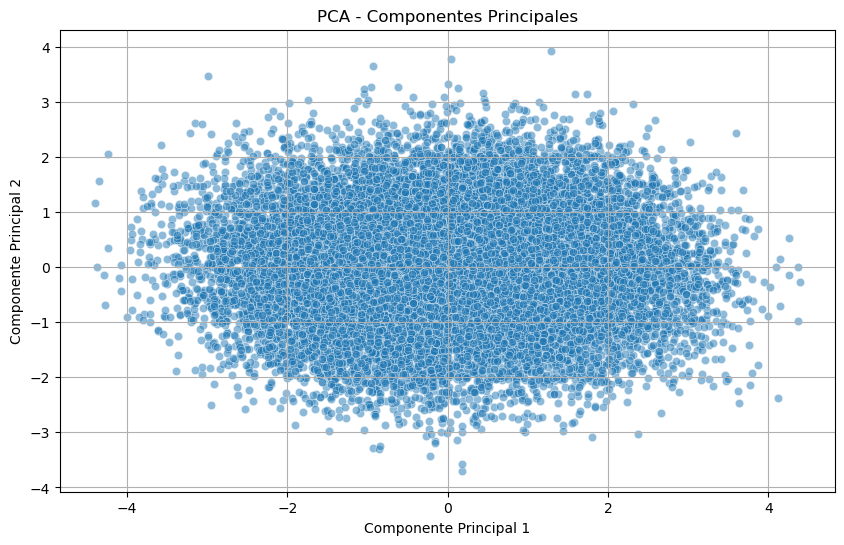

In [79]:
# Mostrar los 4 componentes principales en un gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], alpha=0.5)
plt.title('PCA - Componentes Principales')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid()
plt.show()

In [80]:
# ploteo de los resultados de PCA
# Convertir PCA a DataFrame
#pca_df = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(pca_result.shape[1])])

# Tomar solo los primeros 4 componentes (por ejemplo)
#subset = pca_df.iloc[:, :4]

#sns.pairplot(subset, diag_kind="kde", plot_kws={"alpha":0.5})
#plt.suptitle("Pairplot de Componentes Principales", y=1.02)
#plt.show()

### B. Patrones/clústeres – análisis univariable ###

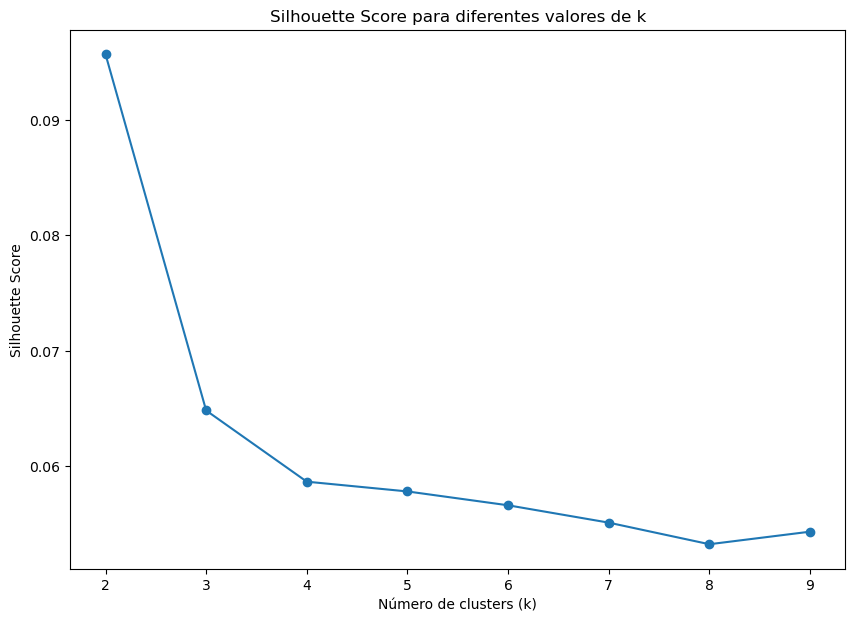

In [81]:
# definir k mediante silhouette score
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

# Graficar los silhouette scores
plt.figure(figsize=(10,7))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score para diferentes valores de k")
plt.show()

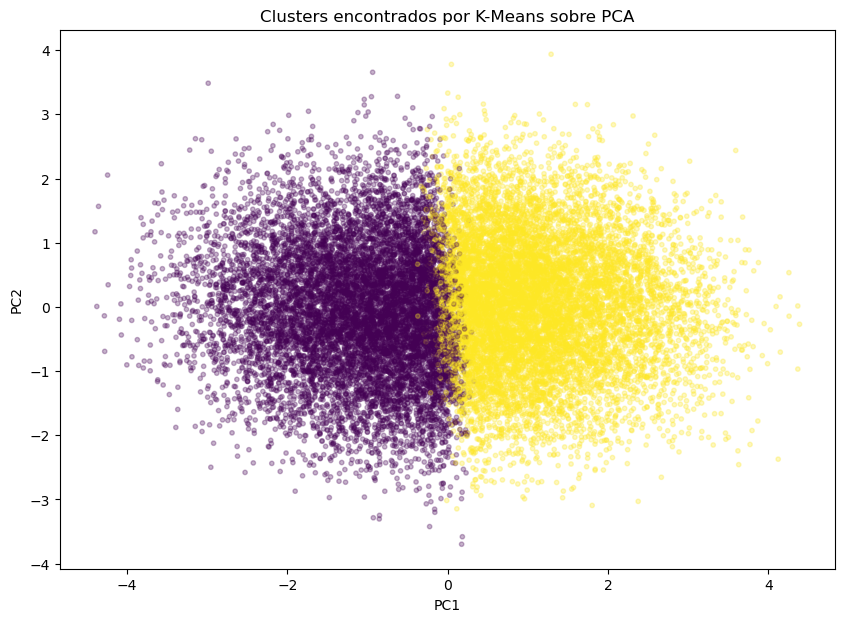

In [82]:
# K-Means para clustering sobre los resultados de PCA
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(pca_result)
labels = kmeans.labels_

# Graficar los clusters
plt.figure(figsize=(10,7))
plt.scatter(pca_result[:,0], pca_result[:,1], c=labels, cmap='viridis', alpha=0.3, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters encontrados por K-Means sobre PCA")
plt.show()

### C. Anomalías – análisis univariable ###

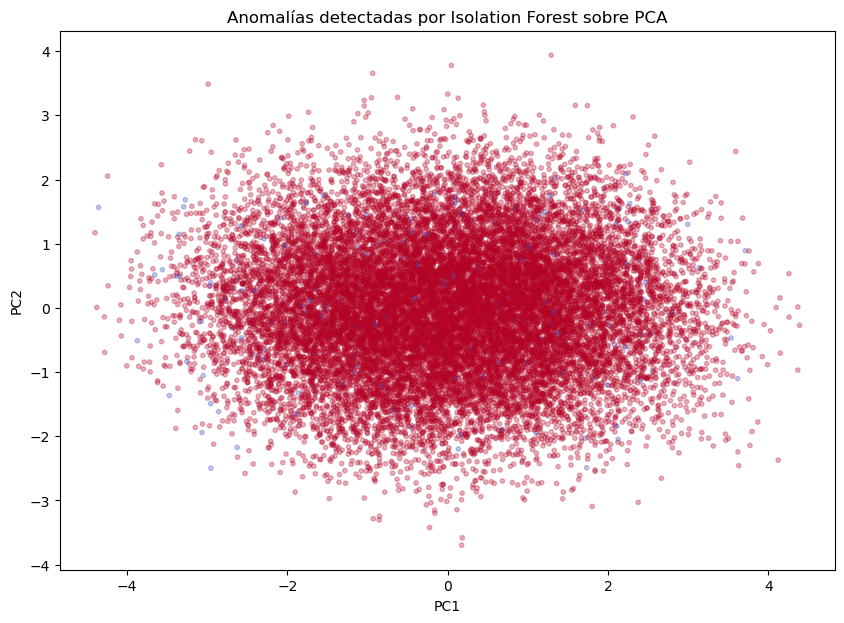

In [83]:
# Análisis de anomalías: puntos que están muy lejos de los clusters
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
anomaly_labels = iso_forest.fit_predict(pca_result)

# Graficar anomalías
plt.figure(figsize=(10,7))
plt.scatter(pca_result[:,0], pca_result[:,1], c=anomaly_labels, cmap='coolwarm', alpha=0.3, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Anomalías detectadas por Isolation Forest sobre PCA")
plt.show()

---
# Secciones 1D, 1E y 1F
## Aprendizaje No Supervisado — SP&BDS (análisis multivariable)



In [84]:
# Imports adicionales para Persona 2
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from matplotlib.lines import Line2D
import numpy as np

# Verificar variables del notebook base
assert 'pca_result' in dir(), 'Falta pca_result — ejecuta primero el notebook de Persona 1'
assert 'anomaly_labels' in dir(), 'Falta anomaly_labels — ejecuta primero el notebook de Persona 1'
assert 'labels' in dir(), 'Falta labels (K-Means 1B) — ejecuta primero el notebook de Persona 1'

print('Variables disponibles del notebook base:')
print(f'  pca_result shape : {pca_result.shape}  → espacio {pca_result.shape[1]}D')
print(f'  labels (1B)      : {np.unique(labels, return_counts=True)}')
print(f'  anomaly_labels   : normal={sum(anomaly_labels==1)}, anomalía={sum(anomaly_labels==-1)}')

Variables disponibles del notebook base:
  pca_result shape : (20000, 12)  → espacio 12D
  labels (1B)      : (array([0, 1], dtype=int32), array([ 9915, 10085]))
  anomaly_labels   : normal=19800, anomalía=200


---
## 1D — Patrones multivariable

Clustering sobre el espacio PCA completo (5 dimensiones, ~60% varianza) usando **2 técnicas**:  
K-Means y Clustering Jerárquico Ward.  
Se compara su consistencia y se identifica el **patrón más representativo**.

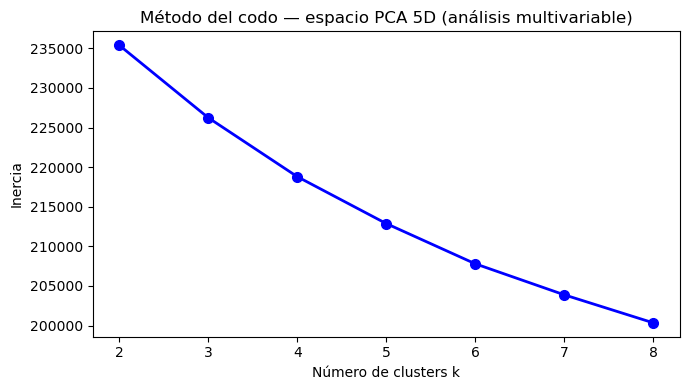

→ Ajusta N_CLUSTERS_M según el codo observado (valor por defecto: 3)


In [85]:
# Método del codo para elegir k óptimo
inertias = []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_result)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_RANGE), inertias, 'bo-', linewidth=2, markersize=7)
plt.xlabel('Número de clusters k')
plt.ylabel('Inercia')
plt.title('Método del codo — espacio PCA 5D (análisis multivariable)')
plt.tight_layout()
plt.show()
print('→ Ajusta N_CLUSTERS_M según el codo observado (valor por defecto: 3)')

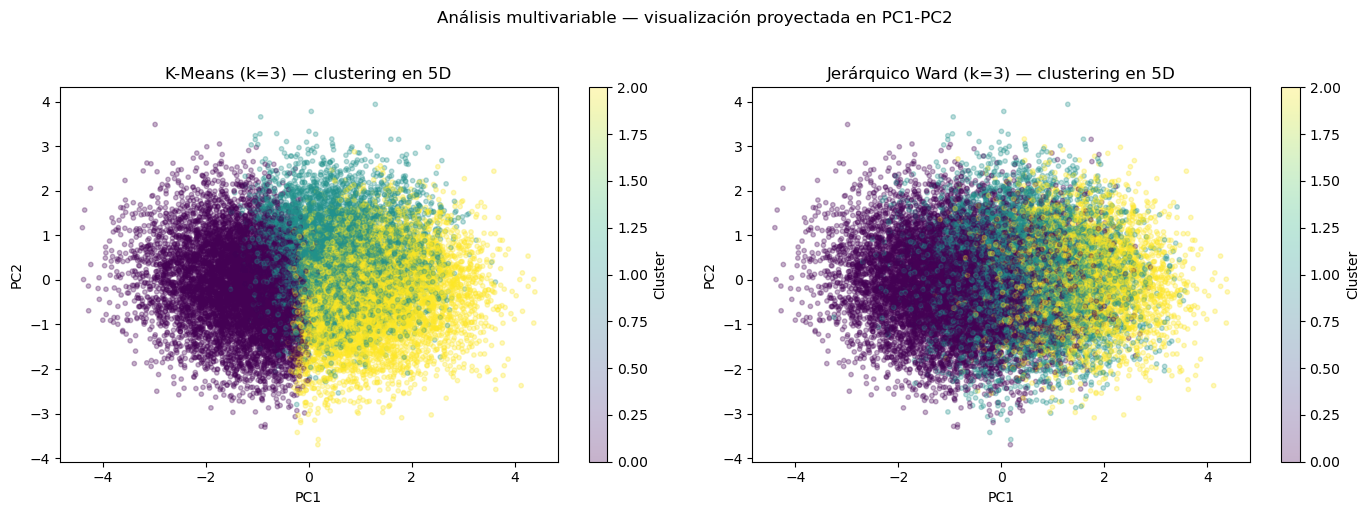

In [86]:
# Ajustar según el codo

N_CLUSTERS_M = 3   

# Técnica 1: K-Means sobre espacio PCA 5D

kmeans_m = KMeans(n_clusters=N_CLUSTERS_M, random_state=42, n_init=10)
labels_kmeans_m = kmeans_m.fit_predict(pca_result)

# Técnica 2: Clustering Jerárquico Ward sobre espacio PCA 5D
agglo_m = AgglomerativeClustering(n_clusters=N_CLUSTERS_M, linkage='ward')
labels_agglo_m = agglo_m.fit_predict(pca_result)

# Visualización comparativa (proyectada en PC1 vs PC2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(pca_result[:,0], pca_result[:,1],
                      c=labels_kmeans_m, cmap='viridis', alpha=0.3, s=10)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title(f'K-Means (k={N_CLUSTERS_M}) — clustering en 5D')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(pca_result[:,0], pca_result[:,1],
                      c=labels_agglo_m, cmap='viridis', alpha=0.3, s=10)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title(f'Jerárquico Ward (k={N_CLUSTERS_M}) — clustering en 5D')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.suptitle('Análisis multivariable — visualización proyectada en PC1-PC2', y=1.02)
plt.tight_layout()
plt.show()

In [87]:
# Métricas de consistencia entre las 2 técnicas
ari_m     = adjusted_rand_score(labels_kmeans_m, labels_agglo_m)
sil_km_m  = silhouette_score(pca_result, labels_kmeans_m)
sil_agg_m = silhouette_score(pca_result, labels_agglo_m)

print('=== Consistencia entre técnicas (1D) ===')
print(f'Adjusted Rand Index (K-Means vs Jerárquico): {ari_m:.3f}')
print(f'  → Cercano a 1.0 = alta consistencia entre técnicas')
print(f'Silhouette K-Means    : {sil_km_m:.3f}')
print(f'Silhouette Jerárquico : {sil_agg_m:.3f}')
print(f'  → Valores más altos = clusters más compactos y separados')

# Patrón más representativo
unique_m, counts_m = np.unique(labels_kmeans_m, return_counts=True)
idx_rep    = np.argmax(counts_m)
patron_rep = unique_m[idx_rep]
pct_rep    = counts_m[idx_rep] / len(labels_kmeans_m) * 100

print(f'\n=== Patrón más representativo ===')
print(f'Cluster {patron_rep}: {counts_m[idx_rep]} estudiantes ({pct_rep:.1f}%)')
print('\nDistribución completa (K-Means):')
for cl, cnt in zip(unique_m, counts_m):
    bar = '█' * int(cnt / len(labels_kmeans_m) * 40)
    print(f'  Cluster {cl}: {bar} {cnt} ({cnt/len(labels_kmeans_m)*100:.1f}%)')

# Comparación 1B (univariable) vs 1D (multivariable)
sil_km_uni = silhouette_score(pca_result, labels)
print(f'\n=== Comparación 1B vs 1D ===')
print(f'  1B K-Means k=2  → Silhouette: {sil_km_uni:.3f}')
print(f'  1D K-Means k={N_CLUSTERS_M}  → Silhouette: {sil_km_m:.3f}  ARI vs Jerárquico: {ari_m:.3f}')

=== Consistencia entre técnicas (1D) ===
Adjusted Rand Index (K-Means vs Jerárquico): 0.217
  → Cercano a 1.0 = alta consistencia entre técnicas
Silhouette K-Means    : 0.067
Silhouette Jerárquico : 0.030
  → Valores más altos = clusters más compactos y separados

=== Patrón más representativo ===
Cluster 0: 7854 estudiantes (39.3%)

Distribución completa (K-Means):
  Cluster 0: ███████████████ 7854 (39.3%)
  Cluster 1: ███████████ 5656 (28.3%)
  Cluster 2: ████████████ 6490 (32.5%)

=== Comparación 1B vs 1D ===
  1B K-Means k=2  → Silhouette: 0.096
  1D K-Means k=3  → Silhouette: 0.067  ARI vs Jerárquico: 0.217


---
## 1E — Anomalías multivariable

Detección de perfiles anómalos sobre el **espacio PCA 5D completo**  
y comparación directa con las anomalías univariables detectadas en 1C.

=== Anomalías detectadas ===
  Univariable  (1C): 200  (1.0%)
  Multivariable(1E): 200 (1.0%)


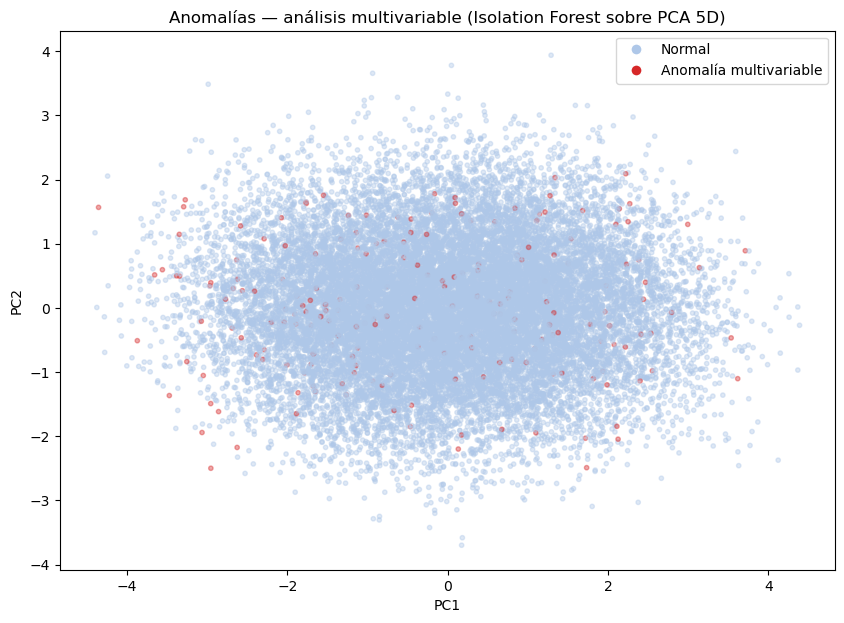

In [88]:
from sklearn.ensemble import IsolationForest as IF

# Isolation Forest multivariable (mismo espacio PCA 5D, misma contamination que 1C)
iso_multi = IF(contamination=0.01, random_state=42)
anomaly_multi  = iso_multi.fit_predict(pca_result)
mask_anom_multi = anomaly_multi == -1
mask_anom_uni   = anomaly_labels == -1   # de 1C

print('=== Anomalías detectadas ===')
print(f'  Univariable  (1C): {mask_anom_uni.sum()}  ({mask_anom_uni.sum()/len(anomaly_labels)*100:.1f}%)')
print(f'  Multivariable(1E): {mask_anom_multi.sum()} ({mask_anom_multi.sum()/len(anomaly_multi)*100:.1f}%)')

# Visualización anomalías multivariable
plt.figure(figsize=(10, 7))
colors_m = ['#d62728' if a == -1 else '#aec7e8' for a in anomaly_multi]
plt.scatter(pca_result[:,0], pca_result[:,1], c=colors_m, alpha=0.4, s=10)
legend_elems = [
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#aec7e8',markersize=8,label='Normal'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#d62728',markersize=8,label='Anomalía multivariable'),
]
plt.legend(handles=legend_elems)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Anomalías — análisis multivariable (Isolation Forest sobre PCA 5D)')
plt.show()

=== Comparación 1C vs 1E ===
  Detectadas solo en multivariable (1E) : 0
  Detectadas solo en univariable (1C)   : 0
  Detectadas por AMBOS métodos          : 200
  → 0 perfiles anómalos adicionales al considerar las variables en conjunto


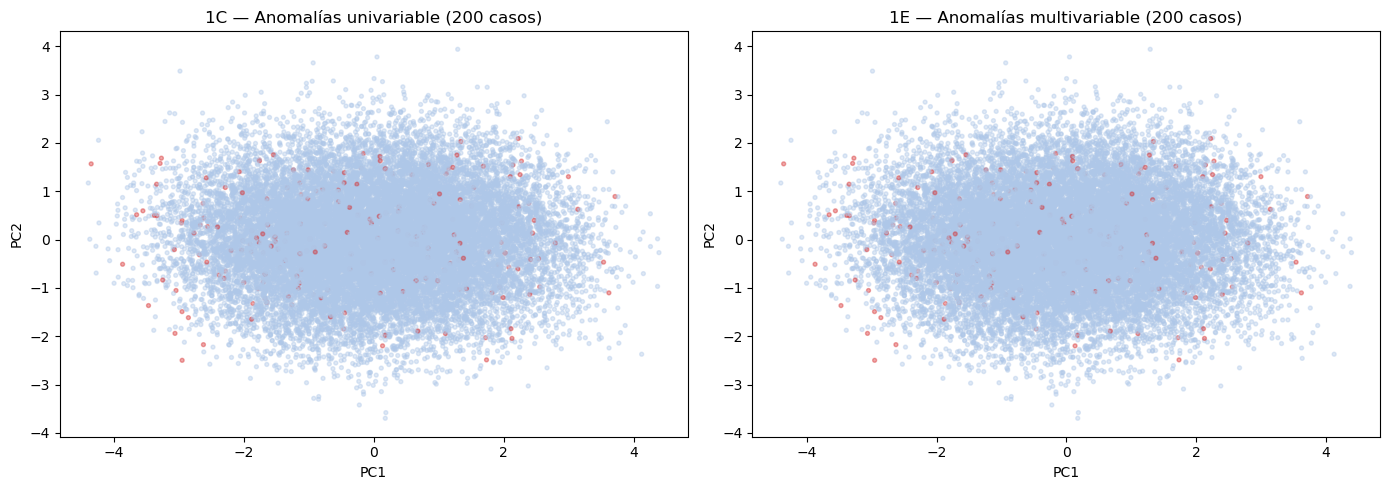


Perfil promedio en PCA — ANÓMALOS multivariable:
                  PC1    PC2    PC3    PC4   PC5    PC6    PC7    PC8    PC9  \
media_anómalos -0.353  0.014  0.085 -0.314 -0.06  0.257  0.044 -0.213 -0.097   

                 PC10   PC11   PC12  
media_anómalos  0.195 -0.476 -0.146  

Perfil promedio en PCA — NORMALES:
                  PC1  PC2    PC3    PC4    PC5    PC6  PC7    PC8    PC9  \
media_normales  0.004 -0.0 -0.001  0.003  0.001 -0.003 -0.0  0.002  0.001   

                 PC10   PC11   PC12  
media_normales -0.002  0.005  0.001  


In [89]:
# Comparación univariable (1C) vs multivariable (1E)
solo_multi = mask_anom_multi & ~mask_anom_uni
solo_uni   = ~mask_anom_multi & mask_anom_uni
ambos      = mask_anom_multi & mask_anom_uni

print('=== Comparación 1C vs 1E ===')
print(f'  Detectadas solo en multivariable (1E) : {solo_multi.sum()}')
print(f'  Detectadas solo en univariable (1C)   : {solo_uni.sum()}')
print(f'  Detectadas por AMBOS métodos          : {ambos.sum()}')
print(f'  → {solo_multi.sum()} perfiles anómalos adicionales al considerar las variables en conjunto')

# Visualización comparativa lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

c_u = ['#d62728' if v else '#aec7e8' for v in mask_anom_uni]
axes[0].scatter(pca_result[:,0], pca_result[:,1], c=c_u, alpha=0.4, s=8)
axes[0].set_title(f'1C — Anomalías univariable ({mask_anom_uni.sum()} casos)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

c_m = ['#d62728' if v else '#aec7e8' for v in mask_anom_multi]
axes[1].scatter(pca_result[:,0], pca_result[:,1], c=c_m, alpha=0.4, s=8)
axes[1].set_title(f'1E — Anomalías multivariable ({mask_anom_multi.sum()} casos)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# Perfil estadístico en espacio PCA
pca_df_full = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])])
print('\nPerfil promedio en PCA — ANÓMALOS multivariable:')
print(pca_df_full[mask_anom_multi].mean().round(3).to_frame('media_anómalos').T)
print('\nPerfil promedio en PCA — NORMALES:')
print(pca_df_full[~mask_anom_multi].mean().round(3).to_frame('media_normales').T)

---
## 1F — Conclusiones del Problema 1

Después de varios intentos, prueba-error, en lugar de fijar n_components=5, ahora se usa PCA(n_components=0.8), lo que le indica a PCA que seleccione automáticamente los componentes necesarios para capturar al menos el 80% de la varianza. Además, antes se había eliminado la variable productivity_score  pero finalmente decidimos no eliminar, solo se eliminan student_id y gender.

1. El dataset tiene estructura continua, no discreta. Los valores de Silhouette entre 0.063 y 0.129 son bajos en todos los análisis. Esto significa que los estudiantes no se agrupan en perfiles claramente diferenciados: existe un espectro continuo de comportamiento entre los extremos.

2. K-Means con k=2 es la partición más estable. Tanto por Silhouette como por simplicidad interpretativa, dividir en 2 grupos (mayor/menor productividad y distracción) es más robusto que k=3.

3. La baja consistencia entre K-Means y clustering jerárquico (ARI=0.162) indica que los grupos no son estructuras robustas en los datos, sino particiones sensibles al algoritmo. Esto refuerza la conclusión anterior: no hay clusters "naturales" bien definidos.

4. Las anomalías son estables. El 1% de estudiantes detectado como anómalo es consistente entre análisis univariable y multivariable, lo que valida que son perfiles genuinamente atípicos.

5. La inclusión de productivity_score, puede estar influyendo en que el PCA concentre más varianza en los primeros componentes y que el clustering encuentre una separación más clara en esa dimensión. Sin embargo, si el objetivo es descubrir patrones de comportamiento de forma no supervisada, incluir la variable objetivo puede sesgar los resultados hacia grupos definidos por productividad en lugar de por hábitos, pero capturar una mejor varianza para visualizar datos fue el criterio que ganó para incluir la variable objetivo.


¿Qué pudieran sugerir los patrones y las anomalías encontradas?

Patrones: los estudiantes se dividen en 2 perfiles generales (mayor equilibrio productivo vs. mayor distracción digital), pero sin una separación clara entre ellos — la mayoría se ubica en zonas intermedias. No existe un perfil "típico" dominante ya que los clusters tienen tamaños similares (~34% cada uno). Esto sugiere que no hay una sola causa que explique la productividad: múltiples factores actúan de forma independiente en cada estudiante.
Anomalías: el 1% de estudiantes (200 personas) presenta perfiles que no encajan en ningún grupo. Su consistencia entre ambos análisis (univariable y multivariable) confirma que son casos genuinamente atípicos, probablemente estudiantes con productividad muy alta o muy baja de forma inexplicable por las variables del dataset.
Implicación principal: no existe una intervención única válida para todos. Los patrones sugieren dos tipos de estrategia pedagógica según el perfil, y los estudiantes anómalos requieren atención individualizada ya que su comportamiento no sigue ninguno de los patrones del grupo.Sonnet 4.6




